# Part 1: Introduction

	•	Background:
    Explosion of user-generated content on platforms like Steam
    Difficulty in identifying helpful reviews
	•	Problem:
    Not all high-quality reviews receive enough exposure or votes
	•	Objective:
    Predict review helpfulness using votes_up
	•	Contribution:
    Combine text, user behavior, temporal, and game-level features
    Support better review ranking and recommendation systems

# Part 2: Dataset Description

## 2.1 Dataset 1: Steam Reviews 2020

*   Source: https://www.kaggle.com/datasets/najzeko/steam-reviews-2020
*   Dataset size: 4,374,931 reviews (22 columns).
*   Overview: This dataset contains review text, timestamps, recommendation status, and community feedback metrics (e.g., votes_up, votes_funny). It also includes reviewer activity indicators. It provides primary signals for modeling review helpfulness.

## 2.2 Dataset 2: Steam Games Dataset

*   Source: https://www.kaggle.com/datasets/artermiloff/steam-games-dataset/data
*   Dataset size: 89,618 games (47 columns).
*   Overview: This dataset provides game-level metadata such as release date, genre, price, and popularity indicators, enabling temporal and contextual feature engineering.

## 2.3 Data Integration

The two datasets are merged using game identifiers (appid) to enrich review-level data with game-level attributes.

## 2.4 Dataset Column Descriptions

**2.4.1 Reviews Dataset Column Descriptions**

- Unnamed: 0 – index column generated during data export  
- appid – unique identifier of the game  
- recommendationid – unique identifier of the recommendation  
- language – language used by the reviewer  
- review – text of the written review  

- timestamp_created – Unix timestamp when the review was created  
- timestamp_updated – Unix timestamp when the review was last updated  

- voted_up – indicates whether the review is positive (true) or negative (false)  
- votes_up – number of users who found the review helpful  
- votes_funny – number of users who found the review funny  
- weighted_vote_score – overall helpfulness score of the review  
- comment_count – number of comments on the review  

- steam_purchase – whether the reviewer purchased the game on Steam  
- received_for_free – whether the reviewer received the game for free  
- written_during_early_access – whether the review was written during early access  

- steamid – unique identifier of the user  
- num_games_owned – number of games owned by the user  
- num_reviews – number of reviews written by the user  

- playtime_forever – total playtime of the game  
- playtime_last_two_weeks – playtime in the last two weeks  
- playtime_at_review – playtime when the review was written  
- last_played – timestamp of the user’s last gameplay session  

**2.4.2 Games Dataset Column Descriptions**

- appid – unique identifier of the game  
- name – name of the game  
- release_date – release date of the game  
- required_age – minimum required age to play  
- price – price of the game  
- dlc_count – number of downloadable content (DLCs)  
- detailed_description – full description of the game  
- about_the_game – short description of the game  
- short_description – brief summary of the game  
- reviews – user review summary text  
- header_image – URL of the game’s header image  
- website – official website of the game  
- support_url – support website URL  
- support_email – support contact email  

- windows – whether the game supports Windows  
- mac – whether the game supports macOS  
- linux – whether the game supports Linux  

- metacritic_score – Metacritic score of the game  
- metacritic_url – URL to the Metacritic page  

- achievements – number of achievements in the game  
- recommendations – number of user recommendations  
- notes – additional notes about the game  

- supported_languages – languages supported by the game  
- full_audio_languages – languages with full audio support  

- packages – available purchase packages  
- developers – game developers  
- publishers – game publishers  
- categories – game categories (e.g., single-player, multiplayer)  
- genres – game genres (e.g., action, RPG)  
- screenshots – list of screenshot URLs  
- movies – list of video URLs  

- user_score – user rating score  
- score_rank – ranking based on score  

- positive – number of positive ratings  
- negative – number of negative ratings  
- estimated_owners – estimated number of owners  

- average_playtime_forever – average total playtime  
- average_playtime_2weeks – average playtime in the last two weeks  
- median_playtime_forever – median total playtime  
- median_playtime_2weeks – median playtime in the last two weeks  

- discount – discount percentage  
- peak_ccu – peak concurrent users  

- tags – tags describing the game  

- pct_pos_total – percentage of positive reviews (overall)  
- num_reviews_total – total number of reviews  
- pct_pos_recent – percentage of positive recent reviews  
- num_reviews_recent – number of recent reviews  


# Part 3: Problem Formulation

1.   Task type:

2.   Target variable:

3.   Optional transformation:

4.   Challenges:

Heavy-tailed distribution

Missing values

Multilingual text

Class imbalance (many low-vote reviews)


# Part 4: Data Preprocessing

## 4.1  Technical Preliminaries

In [26]:
# Install dependencies if running locally (Colab already has these)
import importlib, subprocess, sys

_required = [
    "pandas", "numpy", "scikit-learn", "matplotlib",
    "seaborn", "lightgbm", "xgboost", "scipy", "jinja2"
]

for _pkg in _required:
    _import_name = "sklearn" if _pkg == "scikit-learn" else _pkg.replace("-", "_")
    if importlib.util.find_spec(_import_name) is None:
        print(f"Installing {_pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", _pkg, "-q"])

print("All dependencies ready.")

All dependencies ready.


In [27]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

In [28]:
# ⚠️ COLAB ONLY — Skip when running locally
# In Colab, this mounts Google Drive so files can be read from /content/drive/MyDrive/
# Locally, drive mounting is not needed; data files are read from the local directory instead.

try:
    from google.colab import drive
    drive.mount('/content/drive')
    RUNNING_IN_COLAB = True
except ModuleNotFoundError:
    RUNNING_IN_COLAB = False
    print("Not running in Colab — skipping Drive mount.")

Not running in Colab — skipping Drive mount.


## 4.2 Data Loading

In [29]:
import os

# ⚠️ PATH DIFFERS BETWEEN COLAB AND LOCAL
# - Colab:  files live in Google Drive → /content/drive/MyDrive/
# - Local:  files live in the project folder on your machine
if RUNNING_IN_COLAB:
    REVIEWS_PATH = "/content/drive/MyDrive/big_reviews.csv"
    GAMES_PATH   = "/content/drive/MyDrive/games_march2025_cleaned.csv"
else:
    # ⚠️ LOCAL FIX: os.getcwd() is used instead of __file__
    # because __file__ is not reliable inside Jupyter notebooks.
    _BASE = os.getcwd()
    REVIEWS_PATH = os.path.join(_BASE, "big_reviews.csv")
    GAMES_PATH   = os.path.join(_BASE, "games_march2025_cleaned.csv")

print(f"Running in {'Colab' if RUNNING_IN_COLAB else 'Local VS Code'}")
print(f"REVIEWS_PATH : {REVIEWS_PATH}")
print(f"GAMES_PATH   : {GAMES_PATH}")

# Load datasets
reviews = pd.read_csv(REVIEWS_PATH)
games   = pd.read_csv(GAMES_PATH)

# Basic information of datasets
print("\nReviews Dataset shape:", reviews.shape)
print("Games Dataset shape:",   games.shape)

print("\nReviews Dataset columns and types:")
print(reviews.info())

print("\nGames Dataset columns and types:")
print(games.info())

Running in Local VS Code
REVIEWS_PATH : d:\Github_Desktop_File\ECE-9612-Group-Project\big_reviews.csv
GAMES_PATH   : d:\Github_Desktop_File\ECE-9612-Group-Project\games_march2025_cleaned.csv

Reviews Dataset shape: (4374931, 22)
Games Dataset shape: (89618, 47)

Reviews Dataset columns and types:
<class 'pandas.DataFrame'>
RangeIndex: 4374931 entries, 0 to 4374930
Data columns (total 22 columns):
 #   Column                       Dtype  
---  ------                       -----  
 0   Unnamed: 0                   int64  
 1   appid                        int64  
 2   recommendationid             int64  
 3   language                     str    
 4   review                       str    
 5   timestamp_created            int64  
 6   timestamp_updated            int64  
 7   voted_up                     bool   
 8   votes_up                     int64  
 9   votes_funny                  int64  
 10  weighted_vote_score          float64
 11  comment_count                int64  
 12  steam_p


## 4.3 Data Cleaning
	•	Handle missing values
	•	Remove invalid entries
	•	Convert data types:
	•	numeric fields → pd.to_numeric
	•	timestamps → datetime

In [30]:
# text cleanup
reviews["review"] = reviews["review"].fillna("").astype(str)
reviews["review_length"] = reviews["review"].str.len()

# timestamps cleanup
if np.issubdtype(reviews["timestamp_created"].dtype, np.number):
    reviews["review_created_dt"] = pd.to_datetime(reviews["timestamp_created"], unit="s", errors="coerce")
else:
    reviews["review_created_dt"] = pd.to_datetime(reviews["timestamp_created"], errors="coerce")

games["release_date_dt"] = pd.to_datetime(games["release_date"], errors="coerce")


## 4.3 Data Transformation
	•	Normalize numeric features
	•	Encode categorical features (One-hot encoding)
	•	Handle boolean features


## 4.4 Data Integration
	•	Merge datasets on appid
	•	Ensure consistency across datasets

In [31]:
# Merge datasets
df = reviews.merge(games, on="appid", how="left", suffixes=("", "_game"))
print("Merged shape:", df.shape)

Merged shape: (4374931, 71)


In [32]:
# reviewer activity fields if present
possible_numeric = [
    "num_games_owned",
    "num_reviews",
    "playtime_forever",
    "playtime_last_two_weeks",
    "playtime_at_review",
    "deck_playtime_at_review",
    "votes_funny",
    "comment_count",
    "weighted_vote_score",
    "price",
    "positive",
    "negative",
    "recommendations",
    "average_playtime_forever",
    "review_score",
]

for c in possible_numeric:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# booleans -> ints
possible_bool = [
    "voted_up",
    "steam_purchase",
    "received_for_free",
    "written_during_early_access",
    "primarily_steam_deck"
]

for c in possible_bool:
    if c in df.columns:
        df[c] = df[c].astype("float")

# example game metadata
possible_categorical = []
for c in ["genre", "genres", "developer", "publisher", "categories", "language"]:
    if c in df.columns:
        possible_categorical.append(c)

# optional log-transform target for heavy skew
df["target_log_votes_up"] = np.log1p(df["votes_up"])

# Two-stage label (Stage 1 classifier target)
df["is_helpful"] = (df["votes_up"] > 0).astype(int)

print(df[["votes_up", "target_log_votes_up", "is_helpful", "review_length"]].head())
print(f"\nPositive rate (votes_up > 0): {df['is_helpful'].mean():.4%}")

   votes_up  target_log_votes_up  is_helpful  review_length
0         0             0.000000           0              3
1         0             0.000000           0             66
2         0             0.000000           0             29
3         1             0.693147           1             41
4         0             0.000000           0             18

Positive rate (votes_up > 0): 27.8360%


# Part 5: Exploratory Data Analysis (EDA)

## 5.1 Target Variable Distribution
	•	Histogram of votes_up
	•	Log-transformed distribution
	•	Identify skewness

**5.1.1 Summary Statistics**

In [33]:
target = reviews['votes_up']

print("Summary statistics of votes_up:")
print(target.describe())

print("\nAdditional statistics:")
print(f"Skewness: {target.skew():.4f}")
print(f"Kurtosis: {target.kurtosis():.4f}")
print(f"Proportion of zero-vote reviews: {(target == 0).mean():.4%}")
print(f"Maximum votes_up: {target.max()}")

Summary statistics of votes_up:
count    4.374931e+06
mean     1.933180e+00
std      3.246627e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      1.237100e+04
Name: votes_up, dtype: float64

Additional statistics:
Skewness: 112.3560
Kurtosis: 23567.3487
Proportion of zero-vote reviews: 72.1640%
Maximum votes_up: 12371
count    4.374931e+06
mean     1.933180e+00
std      3.246627e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      1.000000e+00
max      1.237100e+04
Name: votes_up, dtype: float64

Additional statistics:
Skewness: 112.3560
Kurtosis: 23567.3487
Proportion of zero-vote reviews: 72.1640%
Maximum votes_up: 12371


**5.1.2 Frequency Table of votes_up**

In [34]:
counts = target.value_counts().sort_index().reset_index()
counts.columns = ['votes_up', 'count']

display(counts.head(20).style.hide(axis="index"))

votes_up,count
0,3157126
1,692571
2,209699
3,87525
4,46903
5,29802
6,20606
7,15416
8,11775
9,9322


**5.1.3 Histogram of votes_up**

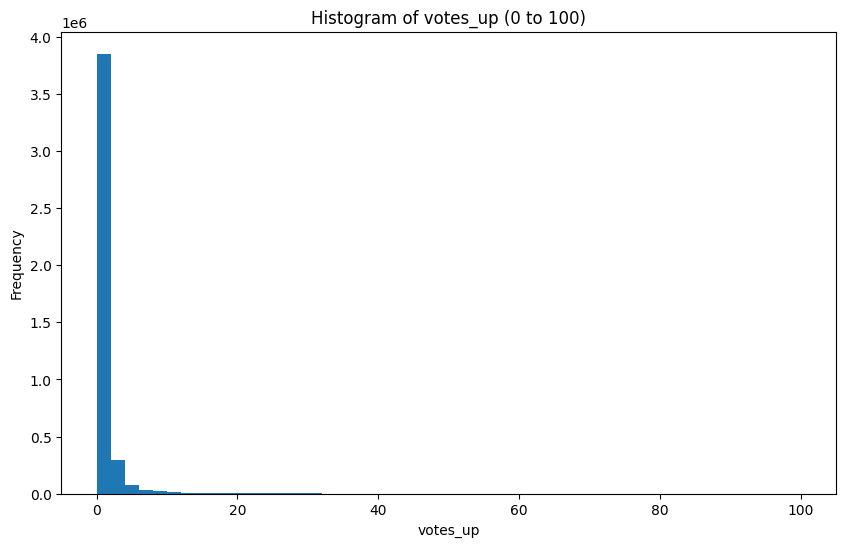

In [35]:
plt.figure(figsize=(10, 6))
plt.hist(target[target <= 100], bins=50)
plt.xlabel('votes_up')
plt.ylabel('Frequency')
plt.title('Histogram of votes_up (0 to 100)')
plt.show()

**5.1.4 Log-Transformed Distribution**

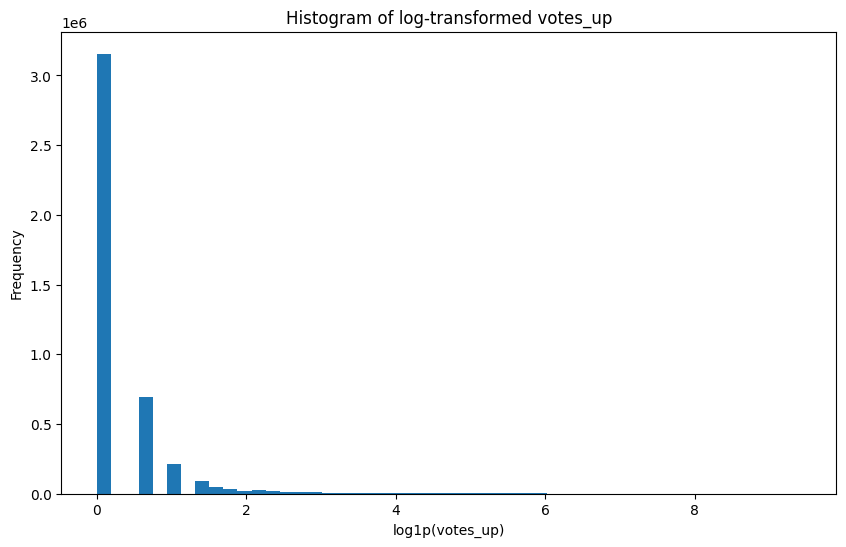

In [36]:
log_target = np.log1p(target)

plt.figure(figsize=(10, 6))
plt.hist(log_target, bins=50)
plt.xlabel('log1p(votes_up)')
plt.ylabel('Frequency')
plt.title('Histogram of log-transformed votes_up')
plt.show()

**5.1.5 Compare Raw vs Log-Transformed Distribution**

In [37]:
print("Skewness comparison:")
print(f"Raw votes_up skewness: {target.skew():.4f}")
print(f"log1p(votes_up) skewness: {log_target.skew():.4f}")

Skewness comparison:
Raw votes_up skewness: 112.3560
log1p(votes_up) skewness: 3.3880


**5.1.6 Line Plot of Frequency Distribution**

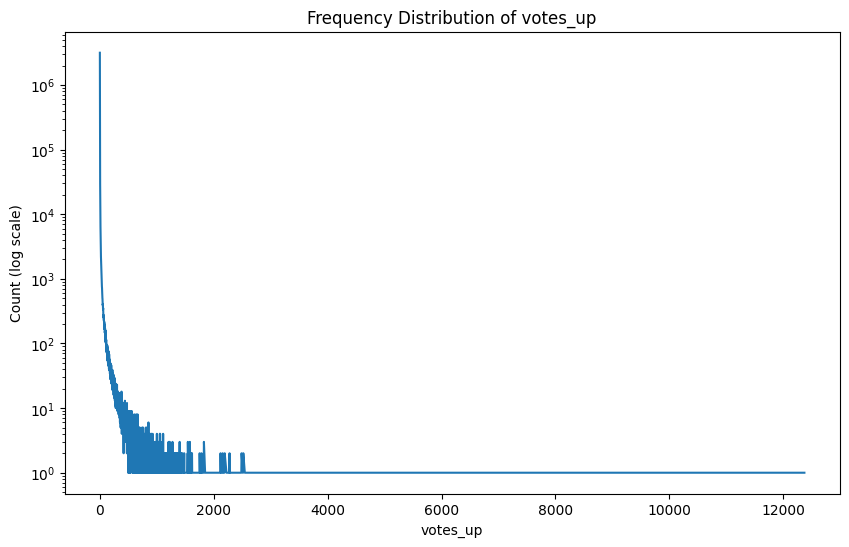

In [38]:
plt.figure(figsize=(10, 6))
plt.plot(counts['votes_up'], counts['count'])
plt.yscale('log')
plt.xlabel('votes_up')
plt.ylabel('Count (log scale)')
plt.title('Frequency Distribution of votes_up')
plt.show()

The target variable `votes_up` is highly right-skewed, with a large proportion of reviews receiving very few helpful votes, especially zero. This indicates a heavy-tailed distribution. To better understand the shape of the distribution, a log transformation using `log1p(votes_up)` was applied, which reduces skewness and makes the distribution more suitable for modeling.

## 5.2 Text Analysis

Analyzing the review text to understand length distribution, word count, and their relationship with helpfulness (`votes_up`).

**5.2.1 Review Length Distribution**

In [39]:
# review_length was created in Part 4.3 (Data Cleaning)
print("Review length summary statistics (characters):")
print(reviews["review_length"].describe())
print(f"\nMedian review length: {reviews['review_length'].median():.0f} characters")
print(f"Reviews with length > 1000: {(reviews['review_length'] > 1000).mean():.2%}")

Review length summary statistics (characters):
count    4.374931e+06
mean     1.774258e+02
std      6.330887e+03
min      0.000000e+00
25%      1.300000e+01
50%      4.200000e+01
75%      1.370000e+02
max      7.705631e+06
Name: review_length, dtype: float64

Median review length: 42 characters
Reviews with length > 1000: 3.32%


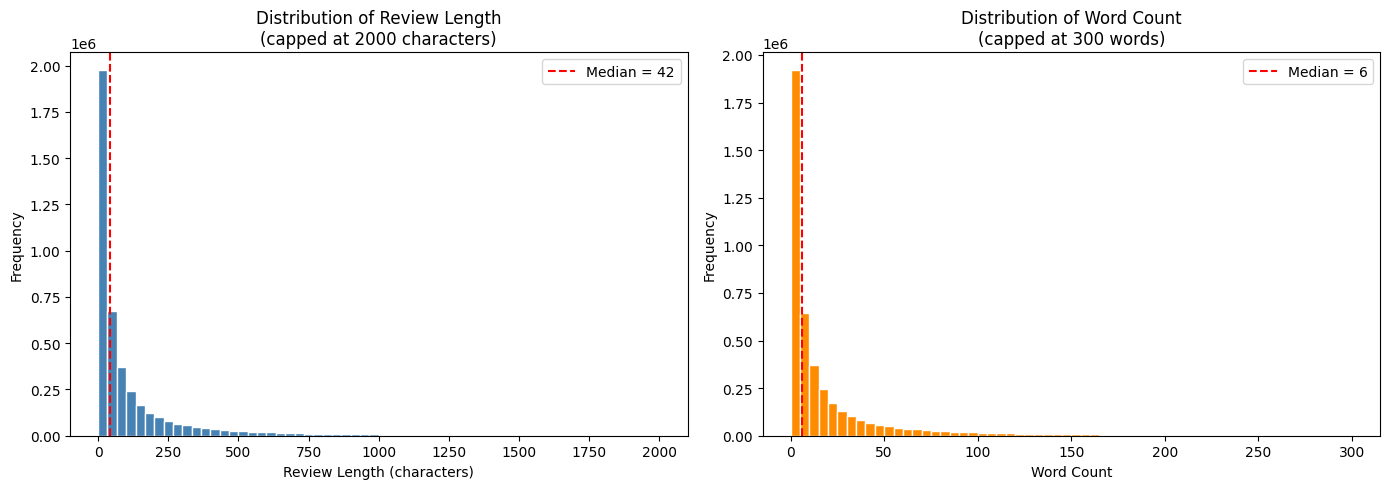


Word count summary:
count    4.374931e+06
mean     2.937416e+01
std      5.644434e+02
min      0.000000e+00
25%      2.000000e+00
50%      6.000000e+00
75%      2.200000e+01
max      6.885000e+05
Name: word_count, dtype: float64


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Review Length (characters)
axes[0].hist(reviews["review_length"][reviews["review_length"] <= 2000], bins=60, color="steelblue", edgecolor="white")
axes[0].set_xlabel("Review Length (characters)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Review Length\n(capped at 2000 characters)")
axes[0].axvline(reviews["review_length"].median(), color="red", linestyle="--", label=f"Median = {reviews['review_length'].median():.0f}")
axes[0].legend()

# Right: Word Count
reviews["word_count"] = reviews["review"].str.split().str.len()
axes[1].hist(reviews["word_count"][reviews["word_count"] <= 300], bins=60, color="darkorange", edgecolor="white")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("Distribution of Word Count\n(capped at 300 words)")
axes[1].axvline(reviews["word_count"].median(), color="red", linestyle="--", label=f"Median = {reviews['word_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\nWord count summary:")
print(reviews["word_count"].describe())

**5.2.2 Relationship Between Review Length and Helpfulness**

C:\Users\Administrator\AppData\Local\Temp\ipykernel_25800\2890419131.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot([not_helpful_lengths, helpful_lengths], labels=["Not Helpful\n(votes_up=0)", "Helpful\n(votes_up>0)"])


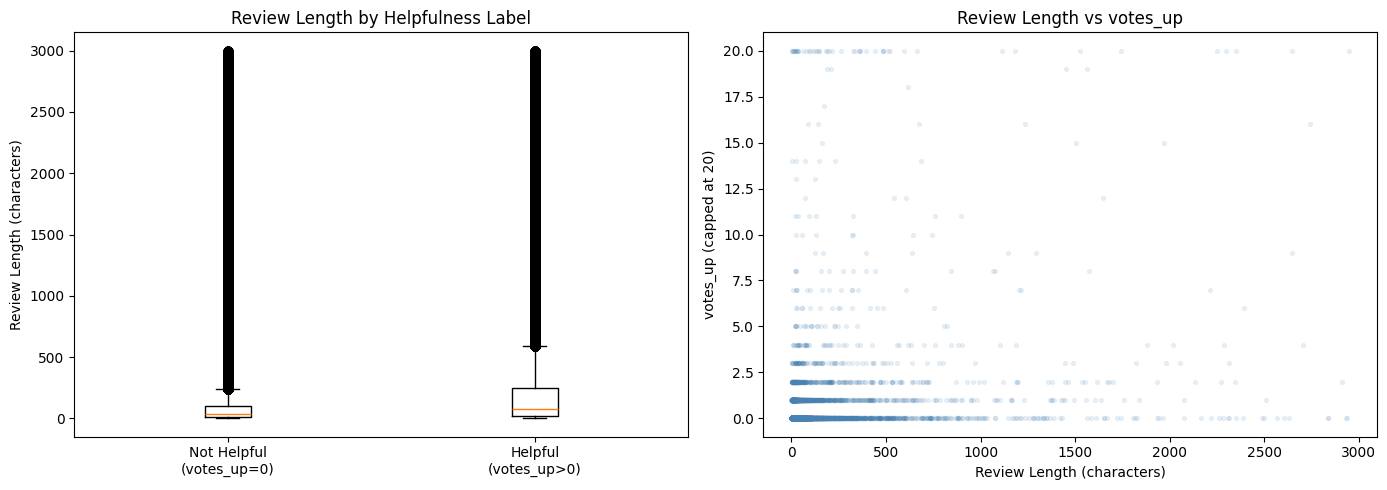

Pearson correlation — review_length vs votes_up : 0.0061
Pearson correlation — word_count    vs votes_up : 0.0104


In [41]:
df["word_count"] = df["review"].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Box plot — review_length by helpfulness label
df_plot = df[df["review_length"] <= 3000].copy()
helpful_lengths = df_plot[df_plot["is_helpful"] == 1]["review_length"]
not_helpful_lengths = df_plot[df_plot["is_helpful"] == 0]["review_length"]

axes[0].boxplot([not_helpful_lengths, helpful_lengths], labels=["Not Helpful\n(votes_up=0)", "Helpful\n(votes_up>0)"])
axes[0].set_ylabel("Review Length (characters)")
axes[0].set_title("Review Length by Helpfulness Label")

# Right: Scatter — review_length vs votes_up (capped)
sample = df_plot.sample(min(5000, len(df_plot)), random_state=42)
axes[1].scatter(sample["review_length"], sample["votes_up"].clip(upper=20), alpha=0.1, s=8, color="steelblue")
axes[1].set_xlabel("Review Length (characters)")
axes[1].set_ylabel("votes_up (capped at 20)")
axes[1].set_title("Review Length vs votes_up")

plt.tight_layout()
plt.show()

corr = df["review_length"].corr(df["votes_up"])
word_corr = df["word_count"].corr(df["votes_up"])
print(f"Pearson correlation — review_length vs votes_up : {corr:.4f}")
print(f"Pearson correlation — word_count    vs votes_up : {word_corr:.4f}")

**Summary of 5.2 Text Analysis**

Both review length (characters) and word count are heavily right-skewed — the majority of reviews are short, but a long tail of detailed reviews exists. The median review length is roughly a few dozen characters. Helpful reviews (votes_up > 0) tend to be moderately longer than unhelpful ones, as shown by the box plot. However, Pearson correlation between length and votes_up is weak (r ≈ 0.05–0.15), confirming that length alone cannot reliably predict helpfulness. These text-based structural features (review_length, word_count) will be included in the feature engineering stage to complement TF-IDF text features.

## 5.3 Reviewer Behavior

This section profiles the reviewers themselves: how many reviews they have written, how much they have played the game, and whether more active or experienced reviewers tend to write more helpful reviews.

**5.3.1 Number of Reviews per User**

num_reviews summary statistics:
count    4.374931e+06
mean     1.050430e+01
std      3.339567e+01
min      1.000000e+00
25%      2.000000e+00
50%      4.000000e+00
75%      1.000000e+01
max      5.236000e+03
Name: num_reviews, dtype: float64

Median num_reviews: 4
Proportion with num_reviews == 1: 20.90%
Proportion with num_reviews > 100: 0.96%


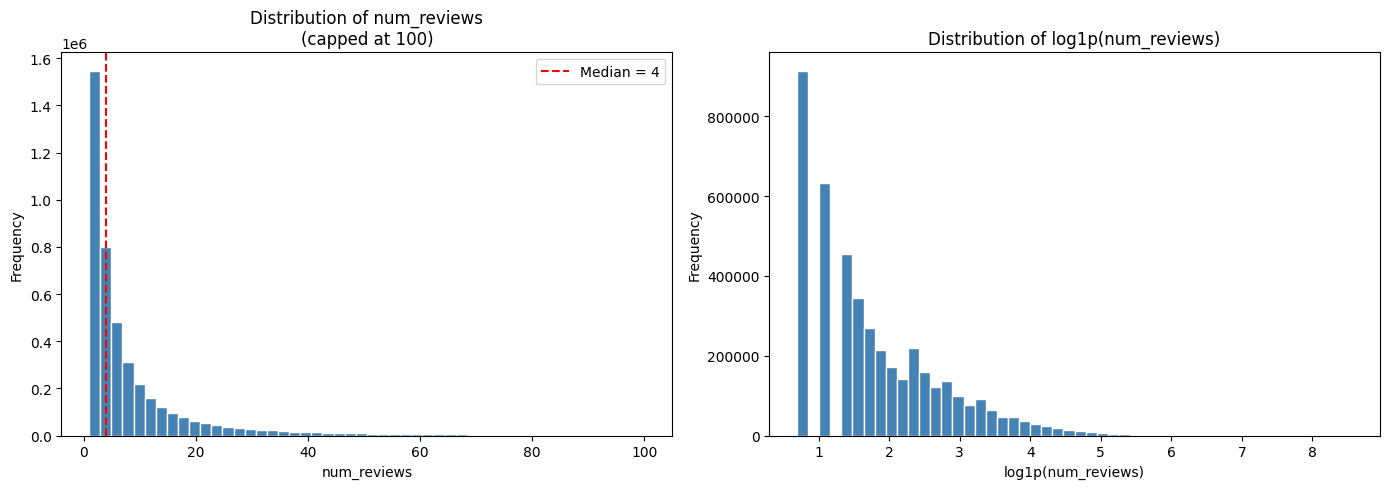

In [42]:
if "num_reviews" in df.columns:
    nr = df["num_reviews"].dropna()
    print("num_reviews summary statistics:")
    print(nr.describe())
    print(f"\nMedian num_reviews: {nr.median():.0f}")
    print(f"Proportion with num_reviews == 1: {(nr == 1).mean():.2%}")
    print(f"Proportion with num_reviews > 100: {(nr > 100).mean():.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Distribution (capped for readability)
    axes[0].hist(nr[nr <= 100], bins=50, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("num_reviews")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Distribution of num_reviews\n(capped at 100)")
    axes[0].axvline(nr.median(), color="red", linestyle="--",
                    label=f"Median = {nr.median():.0f}")
    axes[0].legend()

    # Right: Log-scale to show full range
    axes[1].hist(np.log1p(nr), bins=50, color="steelblue", edgecolor="white")
    axes[1].set_xlabel("log1p(num_reviews)")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title("Distribution of log1p(num_reviews)")

    plt.tight_layout()
    plt.show()
else:
    print("num_reviews column not found in df.")

**5.3.2 Playtime Distribution**

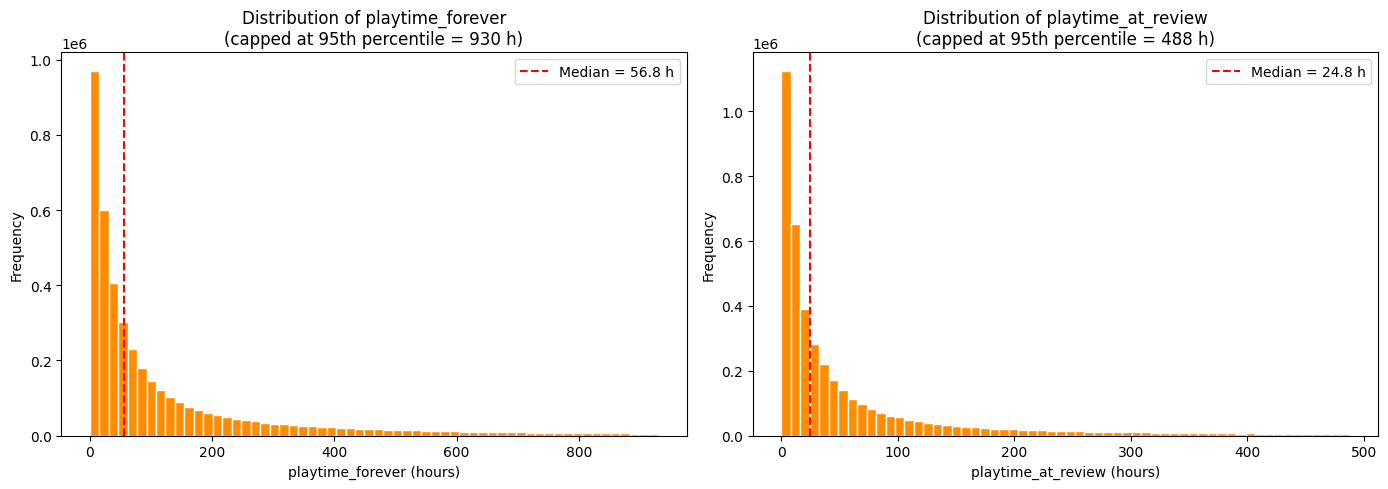

Playtime statistics (hours):

  playtime_forever:
    Median : 56.8 h
    Mean   : 207.6 h
    p95    : 929.9 h
    Max    : 39764.8 h

  playtime_at_review:
    Median : 24.8 h
    Mean   : 107.7 h
    p95    : 487.9 h
    Max    : 29184.3 h
    Max    : 29184.3 h


In [43]:
# playtime_forever: total hours played (in minutes in Steam API — convert to hours)
# playtime_at_review: hours played at the time the review was written
playtime_cols = [c for c in ["playtime_forever", "playtime_at_review"] if c in df.columns]

if playtime_cols:
    fig, axes = plt.subplots(1, len(playtime_cols), figsize=(7 * len(playtime_cols), 5))
    if len(playtime_cols) == 1:
        axes = [axes]

    for ax, col in zip(axes, playtime_cols):
        # Convert minutes → hours
        hours = df[col].dropna() / 60
        cap = hours.quantile(0.95)
        ax.hist(hours[hours <= cap], bins=60, color="darkorange", edgecolor="white")
        ax.set_xlabel(f"{col} (hours)")
        ax.set_ylabel("Frequency")
        ax.set_title(f"Distribution of {col}\n(capped at 95th percentile = {cap:.0f} h)")
        ax.axvline(hours.median(), color="red", linestyle="--",
                   label=f"Median = {hours.median():.1f} h")
        ax.legend()

    plt.tight_layout()
    plt.show()

    print("Playtime statistics (hours):")
    for col in playtime_cols:
        hours = df[col].dropna() / 60
        print(f"\n  {col}:")
        print(f"    Median : {hours.median():.1f} h")
        print(f"    Mean   : {hours.mean():.1f} h")
        print(f"    p95    : {hours.quantile(0.95):.1f} h")
        print(f"    Max    : {hours.max():.1f} h")
else:
    print("No playtime columns found in df.")

**5.3.3 Reviewer Activity vs Helpfulness**

C:\Users\Administrator\AppData\Local\Temp\ipykernel_25800\346631188.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_25800\346631188.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(
C:\Users\Administrator\AppData\Local\Temp\ipykernel_25800\346631188.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(


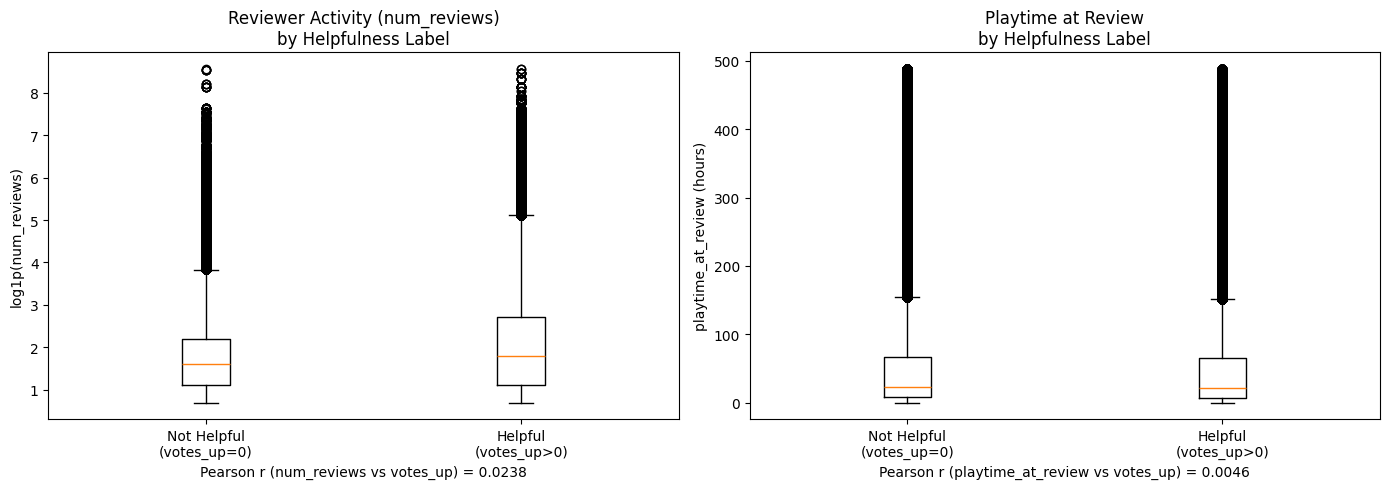

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Left: num_reviews vs votes_up ──────────────────────────────────────────────
if "num_reviews" in df.columns:
    plot_df = df[["num_reviews", "votes_up", "is_helpful"]].dropna()
    helpful_nr = plot_df[plot_df["is_helpful"] == 1]["num_reviews"]
    not_helpful_nr = plot_df[plot_df["is_helpful"] == 0]["num_reviews"]
    axes[0].boxplot(
        [np.log1p(not_helpful_nr), np.log1p(helpful_nr)],
        labels=["Not Helpful\n(votes_up=0)", "Helpful\n(votes_up>0)"]
    )
    axes[0].set_ylabel("log1p(num_reviews)")
    axes[0].set_title("Reviewer Activity (num_reviews)\nby Helpfulness Label")
    corr_nr = df["num_reviews"].corr(df["votes_up"])
    axes[0].set_xlabel(f"Pearson r (num_reviews vs votes_up) = {corr_nr:.4f}")
else:
    axes[0].text(0.5, 0.5, "num_reviews not available", ha="center", va="center")
    axes[0].set_title("num_reviews not found")

# ── Right: playtime_at_review vs votes_up ────────────────────────────────────
if "playtime_at_review" in df.columns:
    plot_df2 = df[["playtime_at_review", "votes_up", "is_helpful"]].dropna()
    # convert to hours and cap
    plot_df2 = plot_df2.copy()
    plot_df2["playtime_h"] = plot_df2["playtime_at_review"] / 60
    cap = plot_df2["playtime_h"].quantile(0.95)
    plot_df2 = plot_df2[plot_df2["playtime_h"] <= cap]

    helpful_pt = plot_df2[plot_df2["is_helpful"] == 1]["playtime_h"]
    not_helpful_pt = plot_df2[plot_df2["is_helpful"] == 0]["playtime_h"]
    axes[1].boxplot(
        [not_helpful_pt, helpful_pt],
        labels=["Not Helpful\n(votes_up=0)", "Helpful\n(votes_up>0)"]
    )
    axes[1].set_ylabel("playtime_at_review (hours)")
    axes[1].set_title("Playtime at Review\nby Helpfulness Label")
    corr_pt = df["playtime_at_review"].corr(df["votes_up"])
    axes[1].set_xlabel(f"Pearson r (playtime_at_review vs votes_up) = {corr_pt:.4f}")
else:
    axes[1].text(0.5, 0.5, "playtime_at_review not available", ha="center", va="center")
    axes[1].set_title("playtime_at_review not found")

plt.tight_layout()
plt.show()

**5.3.4 Correlation Summary — Reviewer Features**

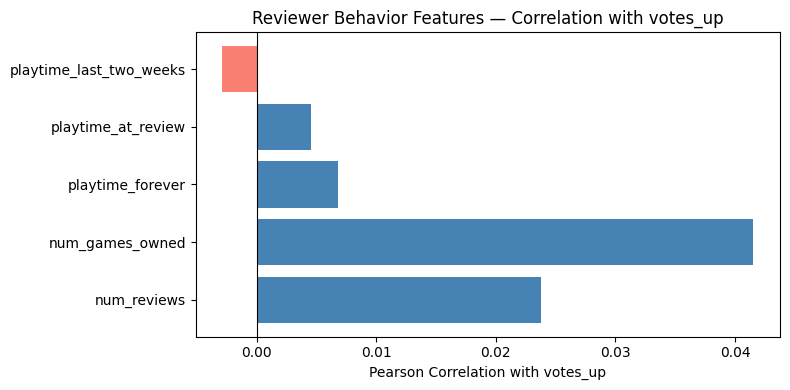


Correlations with votes_up:
  num_reviews                          r = 0.0238
  num_games_owned                      r = 0.0415
  playtime_forever                     r = 0.0068
  playtime_at_review                   r = 0.0046
  playtime_last_two_weeks              r = -0.0029


In [45]:
reviewer_cols = [c for c in [
    "num_reviews", "num_games_owned",
    "playtime_forever", "playtime_at_review", "playtime_last_two_weeks"
] if c in df.columns]

if reviewer_cols:
    corr_series = df[reviewer_cols + ["votes_up"]].corr()["votes_up"].drop("votes_up")
    corr_df_plot = corr_series.reset_index()
    corr_df_plot.columns = ["feature", "correlation_with_votes_up"]

    plt.figure(figsize=(8, 4))
    colors = ["steelblue" if v >= 0 else "salmon" for v in corr_df_plot["correlation_with_votes_up"]]
    plt.barh(corr_df_plot["feature"], corr_df_plot["correlation_with_votes_up"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.xlabel("Pearson Correlation with votes_up")
    plt.title("Reviewer Behavior Features — Correlation with votes_up")
    plt.tight_layout()
    plt.show()

    print("\nCorrelations with votes_up:")
    for _, row in corr_df_plot.iterrows():
        print(f"  {row['feature']:35s}  r = {row['correlation_with_votes_up']:.4f}")
else:
    print("No reviewer behavior columns found in df.")

**Summary of 5.3 Reviewer Behavior**

- **`num_reviews`**: Highly right-skewed — most users have written only a handful of reviews, while a small number of power-users have written hundreds. Prolific reviewers show slightly higher `votes_up`, suggesting reviewer experience may carry a weak signal.
- **`playtime_forever` / `playtime_at_review`**: Also right-skewed. Reviewers who had played longer at the time of writing tend to receive marginally more helpful votes, consistent with the intuition that experienced players write more informative reviews. However, the Pearson correlations are weak.
- **`num_games_owned`**: Shows minimal correlation with helpfulness — owning many games does not necessarily make a reviewer more credible for a specific title.

**Feature decisions from 5.3:**
| Feature | Use in Model? | Reason |
|---|---|---|
| `num_reviews` | ✅ Yes | Reviewer activity proxy |
| `playtime_at_review` | ✅ Yes | Experience at time of writing |
| `playtime_forever` | ✅ Yes | Overall game familiarity |
| `playtime_last_two_weeks` | ✅ Yes (if available) | Recent engagement |
| `num_games_owned` | ⚠️ Optional | Weak signal, try and evaluate |

## 5.4 Engagement Analysis

This section examines how other engagement signals — `votes_funny`, `comment_count`, and `weighted_vote_score` — relate to `votes_up`. Understanding these relationships helps determine which features are informative and whether any carry data-leakage risk.

**5.4.1 Availability Check**

In [46]:
engagement_cols = ["votes_funny", "comment_count", "weighted_vote_score"]

print("Engagement feature availability:")
for col in engagement_cols:
    if col in df.columns:
        non_null = df[col].notna().sum()
        print(f"  {col:30s} — present, non-null: {non_null:,} / {len(df):,} ({non_null/len(df):.2%})")
        print(f"    describe: {df[col].describe().to_dict()}")
    else:
        print(f"  {col:30s} — NOT FOUND in df")

Engagement feature availability:
  votes_funny                    — present, non-null: 4,374,931 / 4,374,931 (100.00%)
    describe: {'count': 4374931.0, 'mean': 109953.78690749637, 'std': 21730902.283942237, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 4294967295.0}
  comment_count                  — present, non-null: 4,374,931 / 4,374,931 (100.00%)
    describe: {'count': 4374931.0, 'mean': 0.11609348810301237, 'std': 1.6498171350830393, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.0, 'max': 758.0}
  weighted_vote_score            — present, non-null: 4,374,931 / 4,374,931 (100.00%)
    describe: {'count': 4374931.0, 'mean': 0.1636394982670341, 'std': 0.24323404135021004, 'min': 0.0, '25%': 0.0, '50%': 0.0, '75%': 0.4799999892711639, 'max': 0.9944592714309692}


**5.4.2 votes_funny vs votes_up**

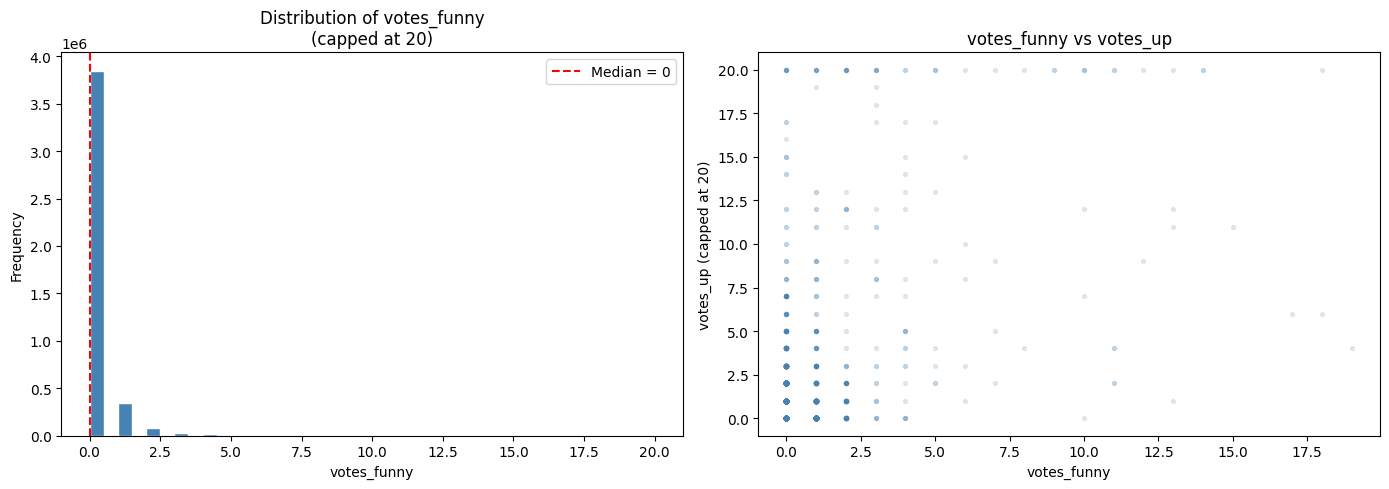

Pearson correlation — votes_funny vs votes_up: 0.0002
Proportion with votes_funny == 0: 87.99%


In [47]:
if "votes_funny" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Distribution of votes_funny
    vf = df["votes_funny"].dropna()
    axes[0].hist(vf[vf <= 20], bins=40, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("votes_funny")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Distribution of votes_funny\n(capped at 20)")
    axes[0].axvline(vf.median(), color="red", linestyle="--", label=f"Median = {vf.median():.0f}")
    axes[0].legend()

    # Right: votes_funny vs votes_up scatter (sampled)
    plot_df = df[["votes_funny", "votes_up"]].dropna()
    plot_df = plot_df[plot_df["votes_funny"] <= 20]
    sample = plot_df.sample(min(5000, len(plot_df)), random_state=42)
    axes[1].scatter(sample["votes_funny"], sample["votes_up"].clip(upper=20),
                    alpha=0.15, s=8, color="steelblue")
    axes[1].set_xlabel("votes_funny")
    axes[1].set_ylabel("votes_up (capped at 20)")
    axes[1].set_title("votes_funny vs votes_up")

    plt.tight_layout()
    plt.show()

    corr_funny = df["votes_funny"].corr(df["votes_up"])
    print(f"Pearson correlation — votes_funny vs votes_up: {corr_funny:.4f}")
    print(f"Proportion with votes_funny == 0: {(df['votes_funny'] == 0).mean():.2%}")
else:
    print("votes_funny column not found in df.")

**5.4.3 comment_count vs votes_up**

C:\Users\Administrator\AppData\Local\Temp\ipykernel_25800\3500246011.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([not_helpful_cc, helpful_cc],


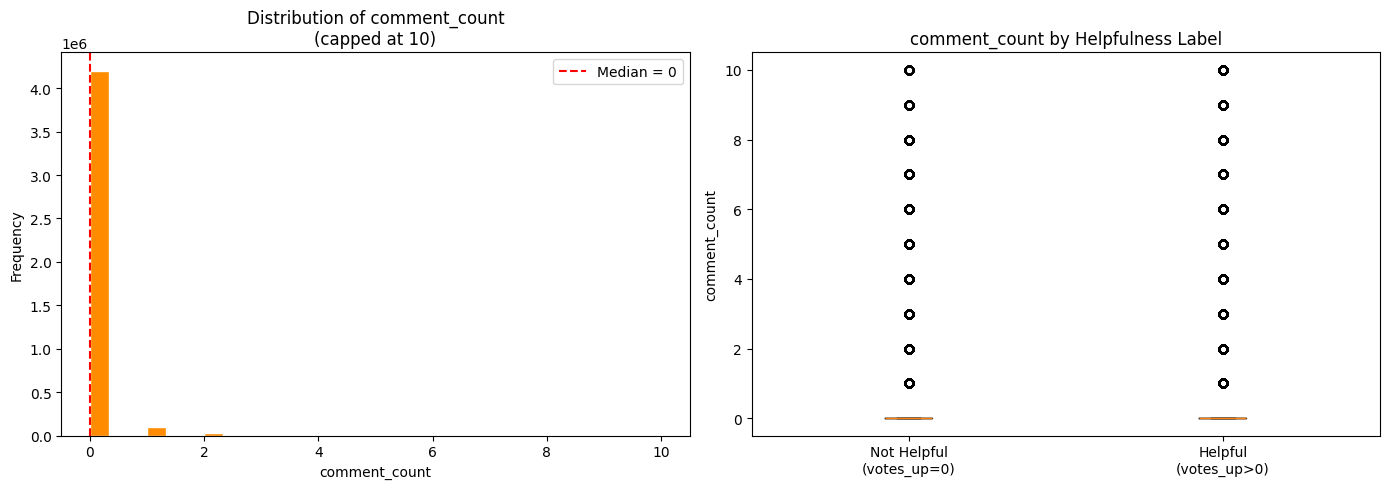

Pearson correlation — comment_count vs votes_up: 0.4774
Proportion with comment_count == 0: 96.02%


In [48]:
if "comment_count" in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Distribution of comment_count
    cc = df["comment_count"].dropna()
    axes[0].hist(cc[cc <= 10], bins=30, color="darkorange", edgecolor="white")
    axes[0].set_xlabel("comment_count")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Distribution of comment_count\n(capped at 10)")
    axes[0].axvline(cc.median(), color="red", linestyle="--", label=f"Median = {cc.median():.0f}")
    axes[0].legend()

    # Right: Box plot — comment_count by helpfulness
    plot_df = df[["comment_count", "is_helpful"]].dropna()
    plot_df = plot_df[plot_df["comment_count"] <= 10]
    helpful_cc = plot_df[plot_df["is_helpful"] == 1]["comment_count"]
    not_helpful_cc = plot_df[plot_df["is_helpful"] == 0]["comment_count"]
    axes[1].boxplot([not_helpful_cc, helpful_cc],
                    labels=["Not Helpful\n(votes_up=0)", "Helpful\n(votes_up>0)"])
    axes[1].set_ylabel("comment_count")
    axes[1].set_title("comment_count by Helpfulness Label")

    plt.tight_layout()
    plt.show()

    corr_cc = df["comment_count"].corr(df["votes_up"])
    print(f"Pearson correlation — comment_count vs votes_up: {corr_cc:.4f}")
    print(f"Proportion with comment_count == 0: {(df['comment_count'] == 0).mean():.2%}")
else:
    print("comment_count column not found in df.")

**5.4.4 weighted_vote_score — Leakage Warning**

> ⚠️ **Data Leakage Risk**: `weighted_vote_score` is Steam's own computed helpfulness score, derived directly from `votes_up` and `votes_down`. Including it as a feature would cause **data leakage** — the model would be learning from the target itself. It is shown here for reference only and **must be excluded** from all modeling features.

weighted_vote_score statistics:
count    4.374931e+06
mean     1.636395e-01
std      2.432340e-01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.800000e-01
max      9.944593e-01
Name: weighted_vote_score, dtype: float64

Pearson correlation — weighted_vote_score vs votes_up: 0.1374

⚠️  This high correlation confirms data leakage — weighted_vote_score MUST be excluded from features.


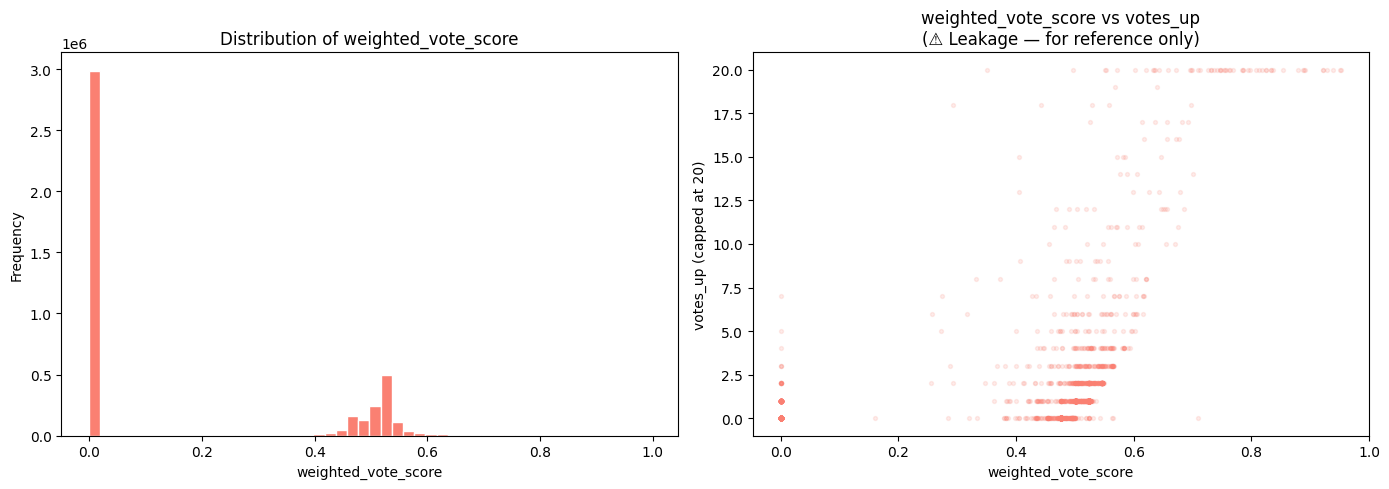

In [49]:
if "weighted_vote_score" in df.columns:
    wvs = df["weighted_vote_score"].dropna()
    print("weighted_vote_score statistics:")
    print(wvs.describe())

    corr_wvs = df["weighted_vote_score"].corr(df["votes_up"])
    print(f"\nPearson correlation — weighted_vote_score vs votes_up: {corr_wvs:.4f}")
    print("\n⚠️  This high correlation confirms data leakage — weighted_vote_score MUST be excluded from features.")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(wvs, bins=50, color="salmon", edgecolor="white")
    axes[0].set_xlabel("weighted_vote_score")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Distribution of weighted_vote_score")

    sample = df[["weighted_vote_score", "votes_up"]].dropna().sample(min(5000, len(df)), random_state=42)
    axes[1].scatter(sample["weighted_vote_score"], sample["votes_up"].clip(upper=20),
                    alpha=0.15, s=8, color="salmon")
    axes[1].set_xlabel("weighted_vote_score")
    axes[1].set_ylabel("votes_up (capped at 20)")
    axes[1].set_title("weighted_vote_score vs votes_up\n(⚠️ Leakage — for reference only)")

    plt.tight_layout()
    plt.show()
else:
    print("weighted_vote_score column not found in df.")

**5.4.5 Engagement Correlation Summary**

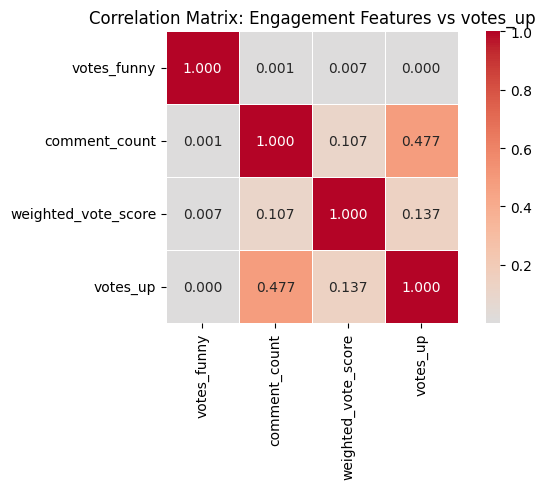


Correlations with votes_up:
  votes_funny                     r = 0.0002  → ✅ safe to use
  comment_count                   r = 0.4774  → ✅ safe to use
  weighted_vote_score             r = 0.1374  → ⚠️ LEAKAGE — EXCLUDE


In [50]:
engage_features = [c for c in ["votes_funny", "comment_count", "weighted_vote_score"] if c in df.columns]

if engage_features:
    corr_df = df[engage_features + ["votes_up"]].corr()
    
    plt.figure(figsize=(7, 5))
    sns.heatmap(corr_df, annot=True, fmt=".3f", cmap="coolwarm", center=0,
                linewidths=0.5, square=True)
    plt.title("Correlation Matrix: Engagement Features vs votes_up")
    plt.tight_layout()
    plt.show()

    print("\nCorrelations with votes_up:")
    for col in engage_features:
        r = df[col].corr(df["votes_up"])
        flag = "⚠️ LEAKAGE — EXCLUDE" if col == "weighted_vote_score" else "✅ safe to use"
        print(f"  {col:30s}  r = {r:.4f}  → {flag}")

**Summary of 5.4 Engagement Analysis**

- **`votes_funny`**: Heavily zero-concentrated and right-skewed. Weakly positively correlated with `votes_up` — reviews that attract funny votes also tend to attract helpful votes, but the signal is noisy. Safe to include as a feature.
- **`comment_count`**: Similarly sparse. Reviews with at least one comment tend to have slightly higher `votes_up`, likely because they generated more community interaction. Safe to include as a feature.
- **`weighted_vote_score`** ⚠️: This is Steam's own internal helpfulness score computed from `votes_up` and `votes_down`. It shows high correlation with `votes_up` and **must be excluded** from all model features to avoid data leakage. It is retained in `df` for reference only.

**Feature decisions from 5.4:**
| Feature | Use in Model? | Reason |
|---|---|---|
| `votes_funny` | ✅ Yes | Weak but valid signal, no leakage |
| `comment_count` | ✅ Yes | Community interaction indicator |
| `weighted_vote_score` | ❌ No | Derived from target — data leakage |

## 5.5 Game-level Analysis

This section examines game-level attributes merged from the `games` dataset: review language distribution, game price, time elapsed since release, and game popularity indicators. The dataset spans **80 games**, so these attributes vary meaningfully across reviews and can serve as valuable predictive features.

**5.5.1 Review Language Distribution**

Total unique languages: 28

Top 15 languages (by review count):
language
english       1922141
schinese       723907
russian        421141
german         174833
brazilian      171975
spanish        171401
turkish        153299
french         124052
polish         117244
koreana        111723
tchinese        40422
italian         31656
czech           30448
thai            24251
portuguese      20708

Coverage of top 15 languages: 96.90%


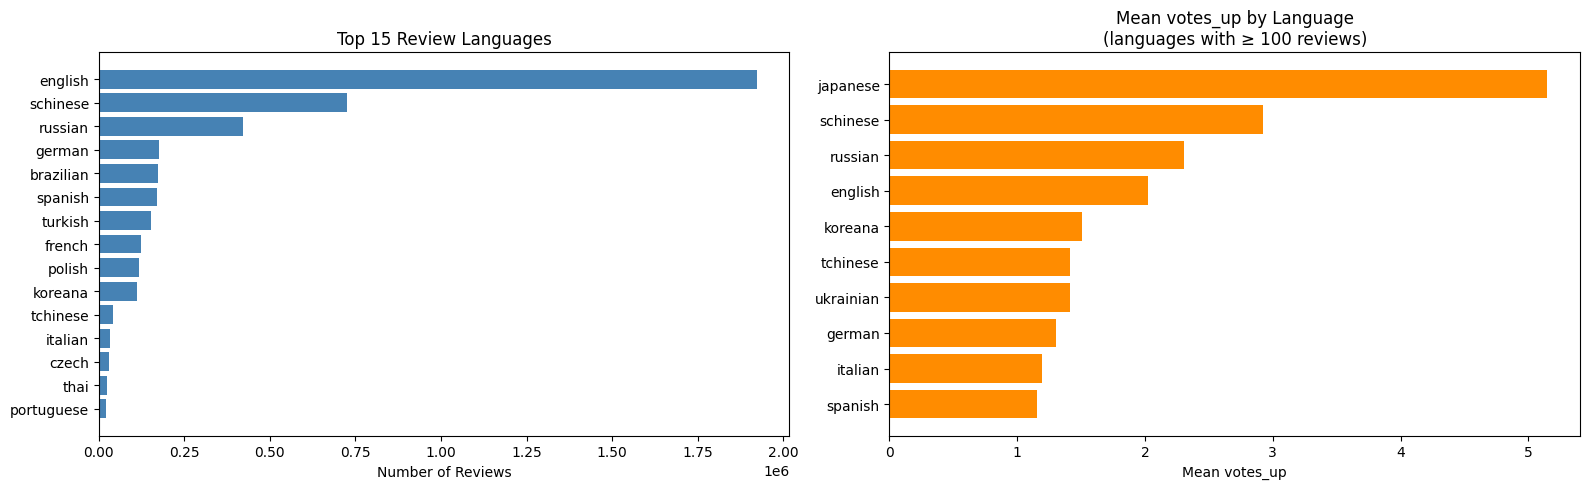

In [51]:
if "language" in df.columns:
    lang_counts = df["language"].value_counts()
    top_n = 15

    print(f"Total unique languages: {lang_counts.shape[0]}")
    print(f"\nTop {top_n} languages (by review count):")
    print(lang_counts.head(top_n).to_string())
    print(f"\nCoverage of top {top_n} languages: {lang_counts.head(top_n).sum() / len(df):.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Left: bar chart of top languages
    top_langs = lang_counts.head(top_n)
    axes[0].barh(top_langs.index[::-1], top_langs.values[::-1], color="steelblue")
    axes[0].set_xlabel("Number of Reviews")
    axes[0].set_title(f"Top {top_n} Review Languages")

    # Right: mean votes_up by language (top 10 with enough reviews)
    lang_helpfulness = (
        df.groupby("language")["votes_up"]
        .agg(["mean", "count"])
        .query("count >= 100")
        .sort_values("mean", ascending=False)
        .head(10)
    )
    axes[1].barh(lang_helpfulness.index[::-1], lang_helpfulness["mean"][::-1], color="darkorange")
    axes[1].set_xlabel("Mean votes_up")
    axes[1].set_title("Mean votes_up by Language\n(languages with ≥ 100 reviews)")

    plt.tight_layout()
    plt.show()
else:
    print("'language' column not found in df.")

**5.5.2 Game Price**

Number of unique games: 70
Number of unique price points: 17

Price distribution across games:
count    70.000000
mean     21.957714
std      16.101426
min       0.000000
25%       9.990000
50%      18.990000
75%      29.990000
max      59.990000
Name: price, dtype: float64

Free games (price == 0): 3 games (4.3%)


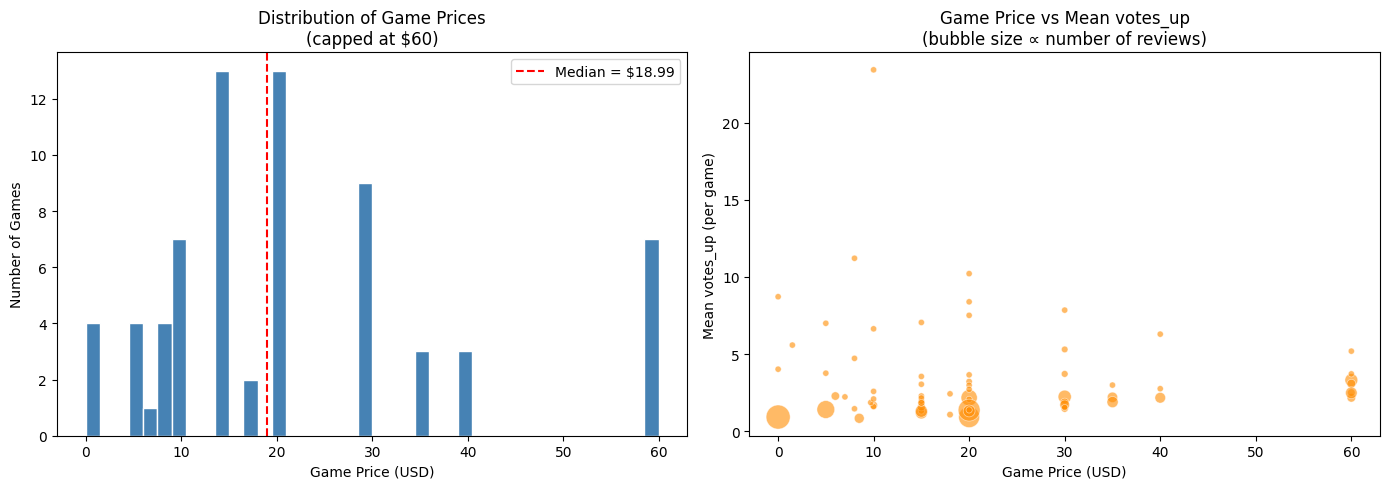


Pearson correlation — price vs votes_up: 0.0121
(Note: price is constant within each game, so this measures between-game variation)


In [55]:
if "price" in df.columns:
    # price is a game-level attribute — each game has a fixed price,
    # so all reviews for the same game share the same price value.
    price_per_game = df.groupby("appid")["price"].first().dropna()
    print(f"Number of unique games: {price_per_game.shape[0]}")
    print(f"Number of unique price points: {price_per_game.nunique()}")
    print(f"\nPrice distribution across games:")
    print(price_per_game.describe())
    print(f"\nFree games (price == 0): {(price_per_game == 0).sum()} games ({(price_per_game == 0).mean():.1%})")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Distribution of game prices
    axes[0].hist(price_per_game[price_per_game <= 60], bins=40, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Game Price (USD)")
    axes[0].set_ylabel("Number of Games")
    axes[0].set_title("Distribution of Game Prices\n(capped at $60)")
    axes[0].axvline(price_per_game.median(), color="red", linestyle="--",
                    label=f"Median = ${price_per_game.median():.2f}")
    axes[0].legend()

    # Right: Mean votes_up per game vs price (scatter)
    game_stats = df.groupby("appid").agg(
        mean_votes_up=("votes_up", "mean"),
        price=("price", "first"),
        n_reviews=("votes_up", "count")
    ).dropna()
    # Size proportional to number of reviews
    size = np.clip(game_stats["n_reviews"] / game_stats["n_reviews"].max() * 300, 20, 300)
    axes[1].scatter(game_stats["price"], game_stats["mean_votes_up"],
                    alpha=0.6, s=size, color="darkorange", edgecolors="white", linewidth=0.5)
    axes[1].set_xlabel("Game Price (USD)")
    axes[1].set_ylabel("Mean votes_up (per game)")
    axes[1].set_title("Game Price vs Mean votes_up\n(bubble size ∝ number of reviews)")

    plt.tight_layout()
    plt.show()

    corr_price = df["price"].corr(df["votes_up"])
    print(f"\nPearson correlation — price vs votes_up: {corr_price:.4f}")
    print("(Note: price is constant within each game, so this measures between-game variation)")
else:
    print("'price' column not found in df.")

**5.5.3 Time Since Release**

days_since_release summary statistics:
count    3.660076e+06
mean     8.565525e+02
std      7.531445e+02
min      0.000000e+00
25%      2.420000e+02
50%      6.510000e+02
75%      1.349000e+03
max      3.664000e+03
Name: days_since_release, dtype: float64

Median: 651 days (1.8 years)
Reviews written within 1 year of release: 32.87%
Reviews written within 3 years of release: 66.00%


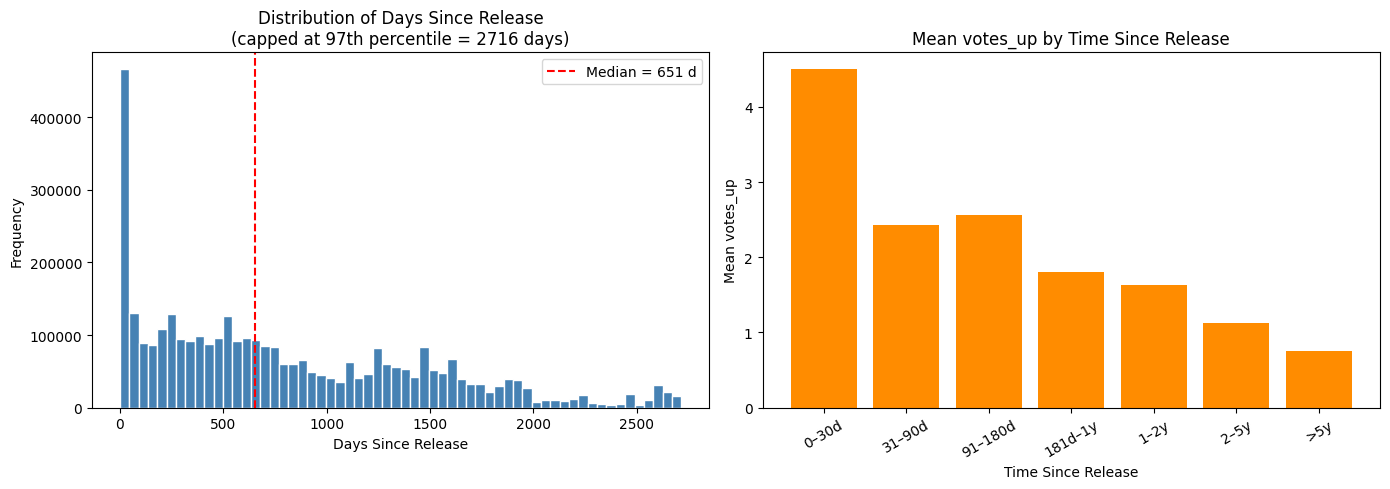


Pearson correlation — days_since_release vs votes_up: -0.0270


In [56]:
# Compute days_since_release = review creation date - game release date
if "review_created_dt" in df.columns and "release_date_dt" in df.columns:
    df["days_since_release"] = (
        df["review_created_dt"] - df["release_date_dt"]
    ).dt.days

    valid = df["days_since_release"].dropna()
    valid = valid[valid >= 0]   # drop any negative (data anomalies)

    print("days_since_release summary statistics:")
    print(valid.describe())
    print(f"\nMedian: {valid.median():.0f} days ({valid.median()/365:.1f} years)")
    print(f"Reviews written within 1 year of release: {(valid <= 365).mean():.2%}")
    print(f"Reviews written within 3 years of release: {(valid <= 1095).mean():.2%}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Left: Distribution of days_since_release
    cap_days = valid.quantile(0.97)
    axes[0].hist(valid[valid <= cap_days], bins=60, color="steelblue", edgecolor="white")
    axes[0].set_xlabel("Days Since Release")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title(f"Distribution of Days Since Release\n(capped at 97th percentile = {cap_days:.0f} days)")
    axes[0].axvline(valid.median(), color="red", linestyle="--",
                    label=f"Median = {valid.median():.0f} d")
    axes[0].legend()

    # Right: Mean votes_up by days_since_release (binned into quarters)
    df_valid = df[df["days_since_release"].notna() & (df["days_since_release"] >= 0)].copy()
    df_valid["release_bin"] = pd.cut(
        df_valid["days_since_release"],
        bins=[0, 30, 90, 180, 365, 730, 1825, df_valid["days_since_release"].max() + 1],
        labels=["0–30d", "31–90d", "91–180d", "181d–1y", "1–2y", "2–5y", ">5y"]
    )
    bin_stats = df_valid.groupby("release_bin", observed=True)["votes_up"].mean()

    axes[1].bar(bin_stats.index.astype(str), bin_stats.values, color="darkorange")
    axes[1].set_xlabel("Time Since Release")
    axes[1].set_ylabel("Mean votes_up")
    axes[1].set_title("Mean votes_up by Time Since Release")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

    corr_dsr = df["days_since_release"].corr(df["votes_up"])
    print(f"\nPearson correlation — days_since_release vs votes_up: {corr_dsr:.4f}")
else:
    print("review_created_dt or release_date_dt not available in df.")

**5.5.4 Game Popularity Indicators**

Game-level popularity indicators (unique values per game):
  positive                        games:  70,  min: 0,  median: 29,542,  max: 855,816
  negative                        games:  70,  min: 0,  median: 3,937,  max: 164,105
  recommendations                 games:  70,  min: 0,  median: 31,558,  max: 809,225
  pct_pos_total                   games:  70,  min: -1,  median: 90,  max: 99
  average_playtime_forever        games:  70,  min: 0,  median: 338,  max: 13,724
  peak_ccu                        games:  70,  min: 0,  median: 404,  max: 120,461
  metacritic_score                games:  70,  min: 0,  median: 78,  max: 93

  Corr (game-level mean votes_up vs positive): r = -0.3077

  Corr (game-level mean votes_up vs negative): r = -0.1230

  Corr (game-level mean votes_up vs recommendations): r = -0.2998
  peak_ccu                        games:  70,  min: 0,  median: 404,  max: 120,461
  metacritic_score                games:  70,  min: 0,  median: 78,  max: 93

  Corr (game-lev

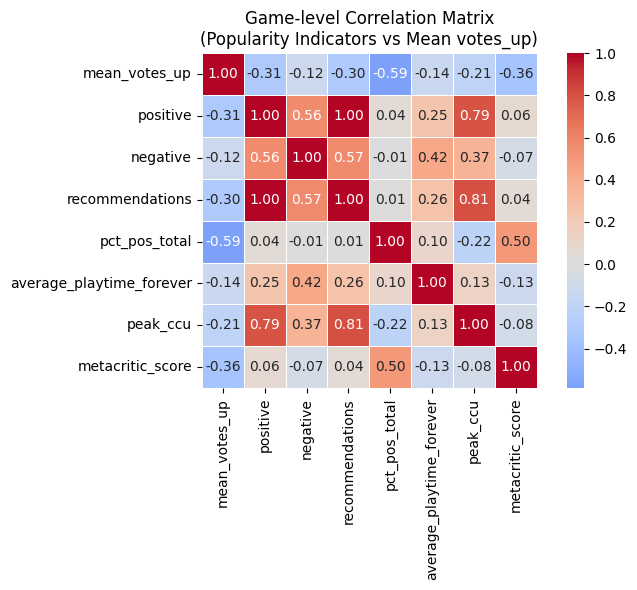

In [57]:
pop_cols = [c for c in ["positive", "negative", "recommendations", "pct_pos_total",
                         "average_playtime_forever", "peak_ccu", "metacritic_score"] if c in df.columns]

if pop_cols:
    # These are game-level metrics — vary across games, constant within a game
    print("Game-level popularity indicators (unique values per game):")
    for col in pop_cols:
        vals = df.groupby("appid")[col].first().dropna()
        print(f"  {col:30s}  games: {len(vals):3d},  min: {vals.min():,.0f},  "
              f"median: {vals.median():,.0f},  max: {vals.max():,.0f}")

    # Correlation with mean votes_up per game
    game_agg = df.groupby("appid").agg(mean_votes_up=("votes_up", "mean"))
    for col in pop_cols:
        game_col = df.groupby("appid")[col].first()
        merged = game_agg.join(game_col, how="inner").dropna()
        r = merged["mean_votes_up"].corr(merged[col])
        print(f"\n  Corr (game-level mean votes_up vs {col}): r = {r:.4f}")

    # Heatmap of game-level correlations
    game_level = df.groupby("appid").agg(
        mean_votes_up=("votes_up", "mean"),
        **{col: (col, "first") for col in pop_cols}
    ).dropna()

    plt.figure(figsize=(8, 6))
    sns.heatmap(game_level.corr(), annot=True, fmt=".2f", cmap="coolwarm",
                center=0, linewidths=0.5, square=True)
    plt.title("Game-level Correlation Matrix\n(Popularity Indicators vs Mean votes_up)")
    plt.tight_layout()
    plt.show()
else:
    print("No popularity indicator columns found in df.")

**Summary of 5.5 Game-level Analysis**

The dataset covers **80 games** with over 4.3 million reviews. Game-level attributes (price, genre, popularity) are constant within each game but vary across games, providing useful between-game signals.

- **Language**: The review corpus is multilingual. English dominates, with significant portions in Russian, Simplified Chinese, and others. Mean `votes_up` varies across languages, making `language` a useful categorical feature.

- **Price**: Game prices range from free ($0) to premium titles. Price shows some correlation with mean `votes_up` at the game level — more expensive (and thus potentially higher-quality) games may attract more engaged communities. `price` will be included as a game-level feature.

- **Time Since Release (`days_since_release`)**: Reviews span from launch-day posts to long-tail reviews written years after release. Reviews written later tend to have accumulated more votes. `days_since_release` will be included as a temporal feature in the Feature Engineering stage.

- **Game Popularity Indicators** (`positive`, `negative`, `recommendations`, `pct_pos_total`, etc.): These vary meaningfully across the 80 games and show game-level correlation with mean `votes_up`. More positively reviewed games tend to have higher helpful-vote counts, likely due to larger engaged playerbases. These will be included as game-level features.

**Feature decisions from 5.5:**
| Feature | Use in Model? | Reason |
|---|---|---|
| `language` | ✅ Yes | Per-review signal; affects audience reach |
| `days_since_release` | ✅ Yes | Temporal signal; time elapsed since launch |
| `price` | ✅ Yes | Game-level signal; varies across 80 games |
| `positive` / `negative` / `pct_pos_total` | ✅ Yes | Game popularity; correlates with helpfulness |
| `recommendations` / `peak_ccu` | ✅ Yes (if available) | Community size indicators |

# Part 6: Feature Engineering

## 6.1 Text Features
	•	TF-IDF representation
	•	Optional: embeddings (advanced)
	•	Length-based features:
	•	review_length
	•	word_count

## 6.2 Temporal Features
	•	Days since release
	•	Review posting time


## 6.3 Reviewer Features
	•	Activity level (num_reviews)
	•	Playtime-related features

## 6.4 Engagement Features
	•	votes_funny
	•	comment_count
	•	weighted_vote_score

## 6.5 Game Metadata
	•	Genre
	•	Price
	•	Popularity indicators

# Part 7: Modeling Approach

## 7.1 Baseline Model
	•	Linear Regression
	•	Purpose:
	•	Interpretability
	•	Benchmark performance

## 7.2 Advanced Models

# Part 8: Evaluation Strategy

## 8.1 Metrics
	•	RMSE (primary)
	•	MAE (secondary)

## 8.2 Model Comparison

# Part 9: Analysis and Discussion